In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from read_roi import read_roi_zip
from collections import OrderedDict, Counter
import math
import PIL
from PIL import Image
from PIL.TiffTags import TAGS
import tkinter as tk
from tkinter import filedialog
import seaborn as sns
from pandas.api.types import CategoricalDtype
import scipy as sp
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color

In [94]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)
path

WindowsPath('C:/Users/sofia/Documents/mcgill/brouhardlab/results/2021_WT_R303X_residence/WT_500pM_100ms/2021-05-13_CH25')

In [95]:
spots = pd.read_csv(path/'Spots in tracks statistics.csv', encoding='utf-8')
data = pd.read_csv(path/'Track statistics.csv', encoding='utf-8')

In [96]:
data

,Label,TRACK_ID,NUMBER_SPOTS,NUMBER_GAPS,LONGEST_GAP,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,TRACK_DURATION,TRACK_START,...,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TRACK_MAX_QUALITY,TRACK_MIN_QUALITY,TRACK_MEDIAN_QUALITY,TRACK_STD_QUALITY
0,Track_0,0,37,2,4,0,0,0,41,0,...,0.453,1.224,0.099,0.427,0.247,10.149,15.260,6.409,9.420,2.049
1,Track_1,1,30,3,4,0,0,0,37,0,...,0.621,1.604,0.082,0.487,0.418,10.015,17.473,6.112,9.335,2.789
2,Track_2,2,2,0,0,0,0,0,1,1,...,0.685,0.685,0.685,0.685,NaN,7.103,7.421,6.786,7.421,0.318
3,Track_3,3,45,7,3,0,0,0,53,0,...,0.577,2.327,0.057,0.446,0.450,8.094,13.243,6.145,7.830,1.564
4,Track_4,4,496,1,1,0,0,0,496,0,...,0.277,1.348,0.017,0.252,0.173,23.729,64.153,6.689,20.921,9.876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9516,Track_9516,9516,2,0,0,0,0,0,1,498,...,0.446,0.446,0.446,0.446,NaN,6.450,6.871,6.028,6.871,0.422
9517,Track_9517,9517,2,0,0,0,0,0,1,498,...,0.176,0.176,0.176,0.176,NaN,7.753,9.153,6.353,9.153,1.400
9518,Track_9518,9518,2,0,0,0,0,0,1,498,...,0.717,0.717,0.717,0.717,NaN,6.133,6.257,6.009,6.257,0.124
9519,Track_9519,9519,2,0,0,0,0,0,1,498,...,0.261,0.261,0.261,0.261,NaN,6.463,6.615,6.311,6.615,0.152


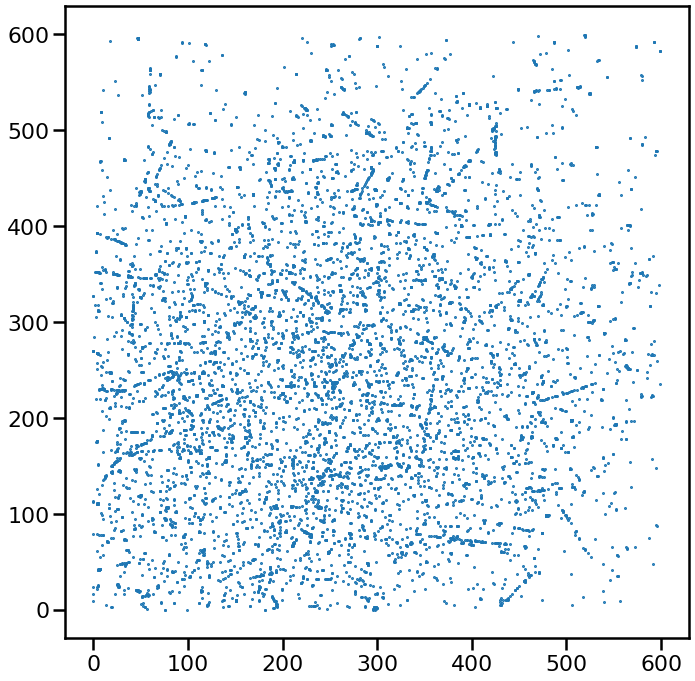

In [97]:
x=data['TRACK_X_LOCATION']
y=data['TRACK_Y_LOCATION']
scattersize = 1
cap = 5
fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
ax.scatter(x , y , s = scattersize)

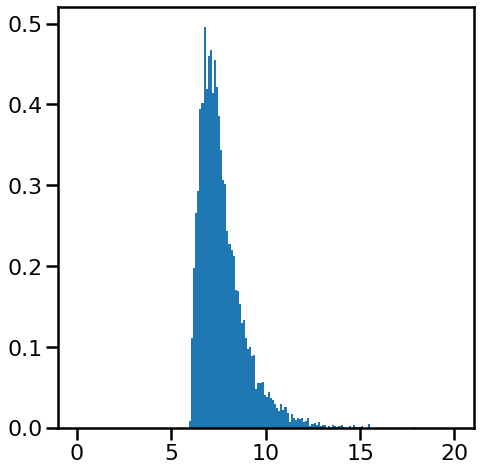

In [98]:
y=data['TRACK_MEDIAN_QUALITY']
scattersize = 1
cap = 5
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(0, 20 + 0.11, 0.11), density=True);

In [99]:
min_duration = 3
data0 = data[(data['TRACK_START']>5) & (data['TRACK_STOP']<495) & (data['TRACK_DURATION']>=min_duration)& (data['TRACK_MEDIAN_QUALITY']>7.5)]
data0

,Label,TRACK_ID,NUMBER_SPOTS,NUMBER_GAPS,LONGEST_GAP,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,TRACK_DURATION,TRACK_START,...,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TRACK_MAX_QUALITY,TRACK_MIN_QUALITY,TRACK_MEDIAN_QUALITY,TRACK_STD_QUALITY
490,Track_490,490,11,1,1,0,0,0,11,7,...,0.655,1.308,0.094,0.580,0.477,8.819,10.801,6.771,8.322,1.380
492,Track_492,492,32,0,0,0,0,0,31,6,...,0.541,0.966,0.064,0.539,0.243,9.320,12.656,6.614,9.264,1.477
493,Track_493,493,19,2,2,0,0,0,21,7,...,0.514,1.282,0.059,0.456,0.317,9.339,12.547,6.558,9.814,2.097
494,Track_494,494,5,0,0,0,0,0,4,6,...,0.281,0.641,0.082,0.270,0.253,8.908,10.268,8.136,8.802,0.775
497,Track_497,497,24,3,4,0,0,0,30,6,...,0.659,1.419,0.072,0.555,0.318,8.887,12.643,6.353,8.845,1.960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9366,Track_9366,9366,5,0,0,0,0,0,4,489,...,0.723,0.993,0.455,0.860,0.247,7.775,9.864,6.316,7.796,1.193
9372,Track_9372,9372,5,0,0,0,0,0,4,490,...,0.552,0.920,0.087,0.777,0.373,10.710,13.498,9.669,10.069,1.409
9374,Track_9374,9374,5,0,0,0,0,0,4,490,...,0.823,1.466,0.393,0.907,0.481,7.561,8.170,7.023,7.560,0.470
9380,Track_9380,9380,5,0,0,0,0,0,4,490,...,0.636,0.701,0.555,0.680,0.067,7.539,8.634,6.199,7.778,0.977


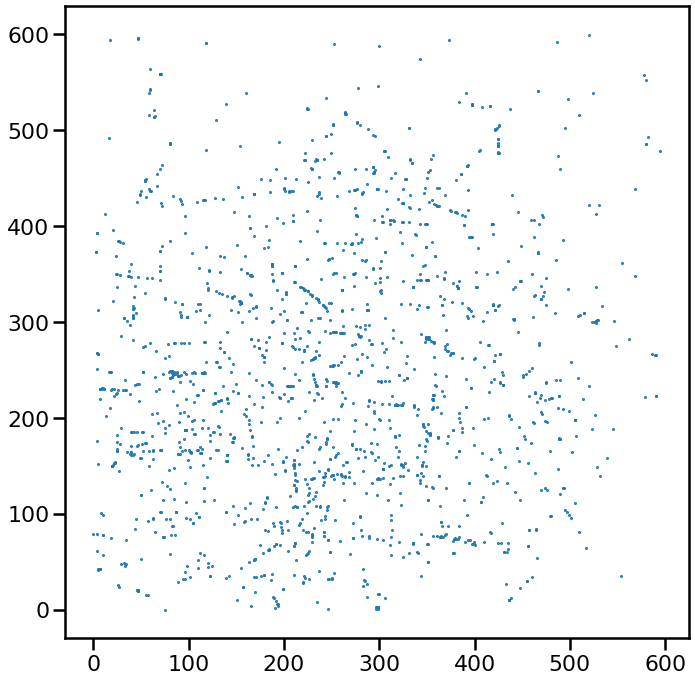

In [100]:
x=data0['TRACK_X_LOCATION']
y=data0['TRACK_Y_LOCATION']
fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
ax.scatter(x , y , s = scattersize)

In [101]:
def filter_neighbors(data0,R,N,iterations):
    
    for k in range(iterations):
        xy = data0[['TRACK_X_LOCATION','TRACK_Y_LOCATION']]
        for i in list(xy.index): #

            xyvalue = xy.loc[i].values
            xvalue = xyvalue[0]
            yvalue = xyvalue[1]

            square = xy[(xy['TRACK_X_LOCATION']<(xvalue+R)) & (xy['TRACK_X_LOCATION']>(xvalue-R)) & (xy['TRACK_Y_LOCATION']<(yvalue+R)) & (xy['TRACK_Y_LOCATION']>(yvalue-R))]

            if (len(square) < N):
                try:
                    data0 = data0.drop(square.index)
                except KeyError:
                     continue

    return data0

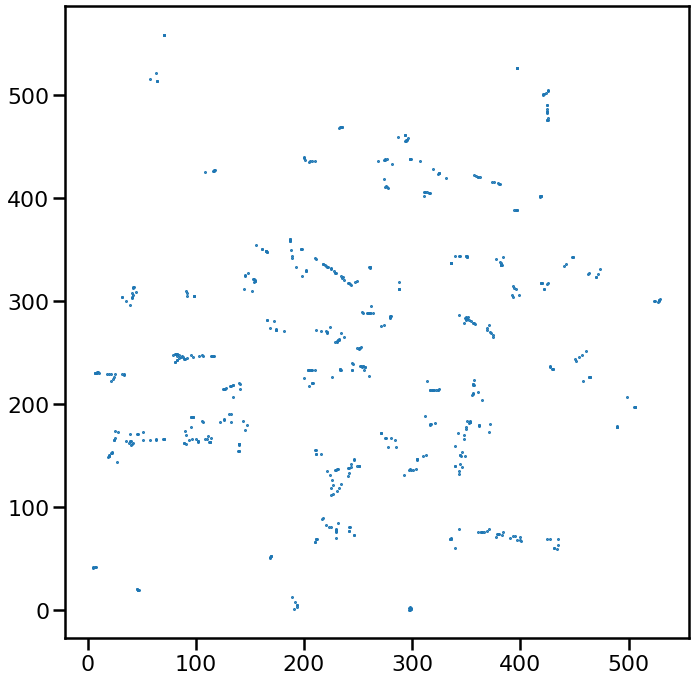

In [102]:
data1 = filter_neighbors(data0,10,5,3)

x=data1['TRACK_X_LOCATION']
y=data1['TRACK_Y_LOCATION']
fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
ax.scatter(x , y , s = scattersize)

## Spots ##

In [103]:
spots

,Label,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,...,MANUAL_COLOR,MEAN_INTENSITY,MEDIAN_INTENSITY,MIN_INTENSITY,MAX_INTENSITY,TOTAL_INTENSITY,STANDARD_DEVIATION,ESTIMATED_DIAMETER,CONTRAST,SNR
0,ID2616921,2616921,0,12.012,202.949,80.176,0,0,0,2.5,...,-10921639,178.189,175,140,217,6593,18.186,2.000,0.038,0.716
1,ID2617383,2617383,0,14.973,202.964,80.292,0,1,1,2.5,...,-10921639,176.946,173,136,220,6547,22.189,2.000,0.043,0.663
2,ID2616085,2616085,0,11.370,203.339,80.766,0,2,2,2.5,...,-10921639,173.730,171,137,219,6428,19.737,4.428,0.034,0.586
3,ID2616495,2616495,0,13.548,203.162,80.377,0,3,3,2.5,...,-10921639,175.568,171,145,234,6496,21.713,2.000,0.050,0.765
4,ID2617807,2617807,0,9.316,203.396,80.702,0,4,4,2.5,...,-10921639,172.486,174,142,217,6382,16.601,2.000,0.034,0.682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68956,ID2718699,2718699,9518,6.257,363.969,91.322,0,499,499,2.5,...,-10921639,156.541,151,135,200,5792,16.276,2.000,0.026,0.483
68957,ID2718549,2718549,9519,6.311,155.210,111.477,0,498,498,2.5,...,-10921639,155.892,156,130,179,5768,12.481,8.929,0.020,0.498
68958,ID2718704,2718704,9519,6.615,155.421,111.322,0,499,499,2.5,...,-10921639,155.838,153,132,197,5766,16.616,2.000,0.025,0.465
68959,ID2718548,2718548,9520,6.357,282.872,106.386,0,498,498,2.5,...,-10921639,155.405,153,131,185,5750,12.913,2.000,0.011,0.250


In [106]:
trackID = data1['TRACK_ID']
filteredspots = spots[spots['TRACK_ID'].isin(trackID)]

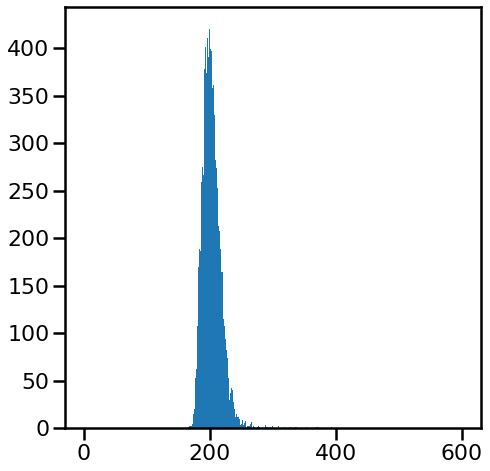

In [107]:
y=filteredspots['MAX_INTENSITY']
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(0, 600 + 1, 1));

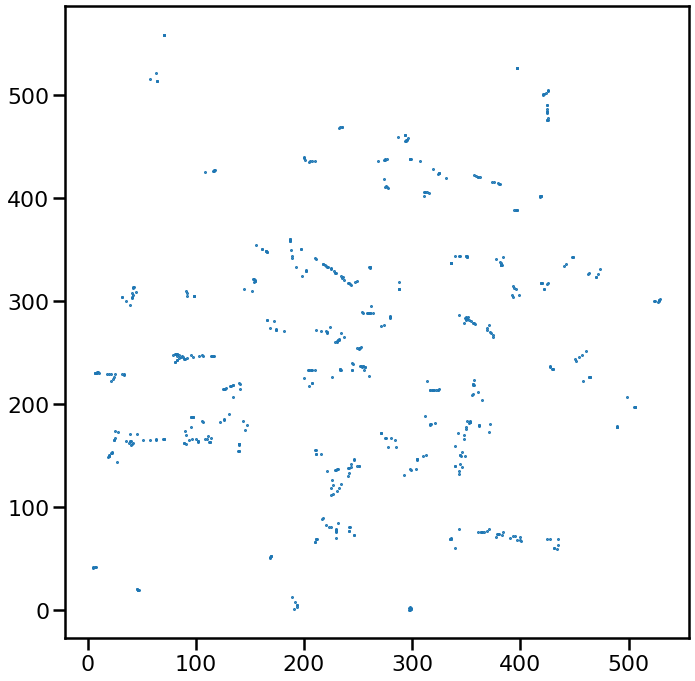

In [108]:
brightspotsID = filteredspots[filteredspots['MAX_INTENSITY'] > 250]['TRACK_ID'].unique()
data1 = data1[~data1['TRACK_ID'].isin(brightspotsID)]


x=data1['TRACK_X_LOCATION']
y=data1['TRACK_Y_LOCATION']
fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
ax.scatter(x , y , s = scattersize)

## Exponential Fit ##

In [109]:
def exponential(x, scale):
    return ((np.exp(-(x)/scale) )/(scale))
def equation_fit(track_duration):
    
    equation = exponential
        
    results = pd.DataFrame(columns=[] , index=[])
    
    n, bins, patches = ax.hist(track_duration, bins=np.arange(0, 150 + 1, 1), density=True);
                
    coeff, var_matrix = sp.optimize.curve_fit(equation,bins[:-1],n)

    variance = np.diagonal(var_matrix) #Refer [3]
    SE = np.sqrt(variance) #Refer [4]

            #======Making a data frame========
    results0 = pd.DataFrame(columns=[] , index=[])
    
    for k in np.arange(0,len(coeff)):
        header = [np.array(['Exponential']),np.array(['Coefficient '+ str(k)])]
        r0 = pd.DataFrame([coeff[k],SE[k]], index=(['Value','SE']),columns= header)
        results0 = pd.concat([results0, r0], axis=1, sort=False)

    results = pd.concat([results, results0], sort=False)

    return results

In [110]:
spf = 0.1
DCXconc=str(0.5)

track_duration=(data1['TRACK_DURATION'])*spf
track_duration_shift=(track_duration.add(-min_duration*spf)) #times 100ms
EqFit = equation_fit(track_duration_shift)

#EqFit.loc['Value'] = EqFit.loc['Value'].add((min_duration-1)*spf)

scale = EqFit['Exponential']['Coefficient 0'].loc['Value']
#x0 = EqFit['Exponential']['Coefficient 1'].loc['Value']
EqFit

,Exponential
,Coefficient 0
Value,1.880666
SE,0.044187


In [111]:
black = '#000000'
grey = '#777777'
blue = '#23459C'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
yellow = '#FFCB05'
Purple = Color(purple)
DC1color = list(Purple.range_to(Color(magenta),2))
Yellow = Color(yellow)
DC2color = list(Yellow.range_to(Color(orange),3))
print(DC1color,DC2color)

[<Color #ab4a9c>, <Color #d80b8c>] [<Color #ffcb05>, <Color #ff9f02>, <Color #ff7300>]


In [112]:
true_scale = EqFit['Exponential']['Coefficient 0'].loc['Value']+((min_duration-1)*spf)
SE = EqFit['Exponential']['Coefficient 0'].loc['SE']
scalestr = str(round(true_scale,1))
SEstr = str(round(SE,2))
scalestr,SEstr

('2.1', '0.04')

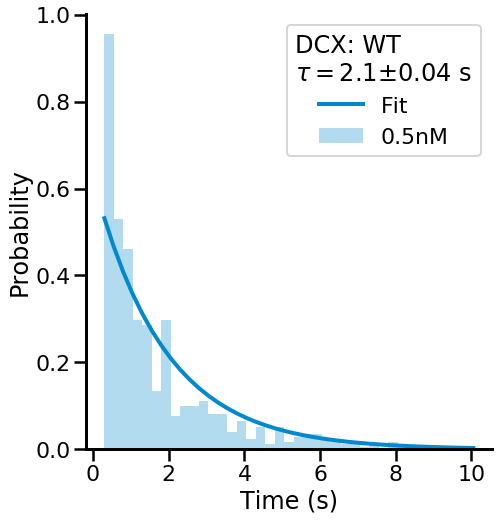

In [113]:
color=cyan
xlim = 10
bins = 0.25


x = np.arange(min_duration*spf, xlim + bins, bins)
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(track_duration, bins=x, density=True,color = color,alpha = 0.3);
ax.plot(x,exponential(x-(min_duration*spf),scale),color = color, lw=4);
ax.set_xlabel('Time (s)')
ax.set_ylabel('Probability')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_lw(3)
ax.spines['bottom'].set_lw(3)

ax.legend(('Fit',DCXconc + 'nM'),loc='upper right',title='DCX: WT \n' r'$\tau = $' + scalestr + r'$\pm $'  + SEstr + ' s')

sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
plt.tight_layout()
plt.savefig(path/('track-duration_expo-fit.pdf'))